### SECTION 1 — Кітапханаларды импорттау
Бұл бөлімде жобаға қажетті негізгі құралдар жүктеледі:
* **Pandas & Numpy:** Деректерді өңдеу және массивтермен жұмыс істеу үшін.
* **Matplotlib & Seaborn:** Деректерді визуализациялау (графиктер салу) үшін.
* **Scikit-learn:** Машиналық оқыту модельдері, деректерді дайындау және метрикаларды есептеу үшін.

Жүрек ауруын анықтауда классикалық ML алгоритмдері мен ансамбльдік модельдерді салыстырмалы талдау
Бұл жобаның мақсаты — жүрек ауруын анықтау үшін
машиналық оқыту алгоритмдерін қолдану.

Жобада:
- Logistic Regression
- Random Forest
модельдері салыстырылды.

Сонымен қатар гиперпараметрлерді баптау үшін
GridSearchCV қолданылды.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

### SECTION 2 — Деректер жиынтығын жүктеу
Бұл қадамда `heart.csv` файлы бағдарламаға оқу үшін жүктеледі. Бұл деректер жиынтығында пациенттердің медициналық көрсеткіштері мен оларда жүрек ауруының бар-жоғы туралы ақпарат сақталған.

In [60]:
df = pd.read_csv("C:/Users/Admin/Documents/Ansagan/midterm_project/data/heart.csv")

### SECTION 3 — Алғашқы деректерді талдау
Деректердің құрылымын түсіну:
* `head()`: Алғашқы жолдарды көру.
* `info()`: Бағандардың типін және бос ұяшықтардың (null) бар-жоғын тексеру.
* `describe()`: Сандық деректердің статистикалық сипаттамасын (орташа мән, минимум, максимум) алу.

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


<Axes: >

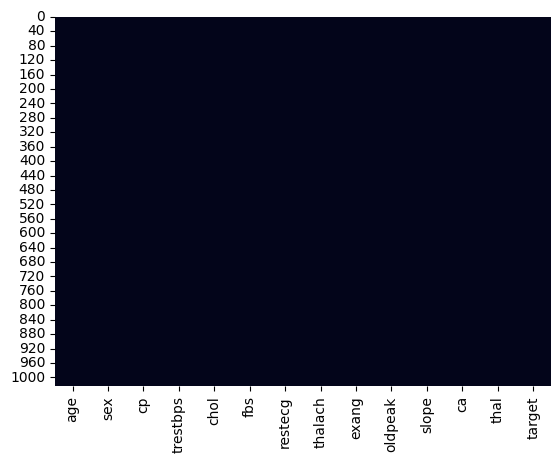

In [91]:
df.head()
df.info()
df.describe()
df.shape
df.columns
sns.heatmap(df.isnull(), cbar=False)

### SECTION 4 — Зерттеушілік деректер талдауы (EDA)
Мұнда біз деректердің ішкі байланыстарын көзбен көреміз:
* **Target Distribution:** Кластардың тепе-теңдігін тексеру.
* **Correlation Heatmap:** Қай көрсеткіштердің бір-біріне немесе аурудың бар-жоғына (target) қатты әсер ететінін анықтау.
* **Histograms:** Әрбір белгінің (feature) таралуын көру.

4.1 Target Distribution

<Axes: xlabel='target', ylabel='count'>

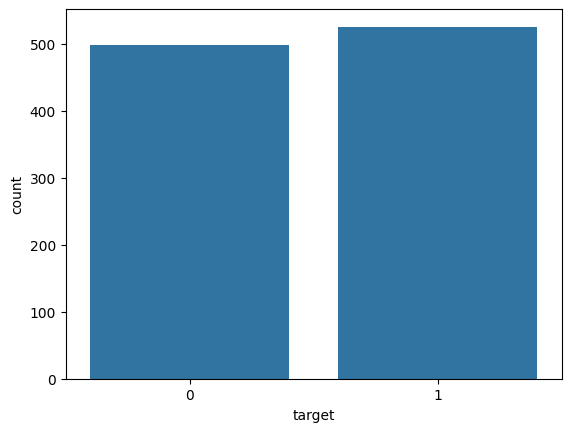

In [62]:
sns.countplot(x='target', data=df)

4.2 Correlation Heatmap

<Axes: >

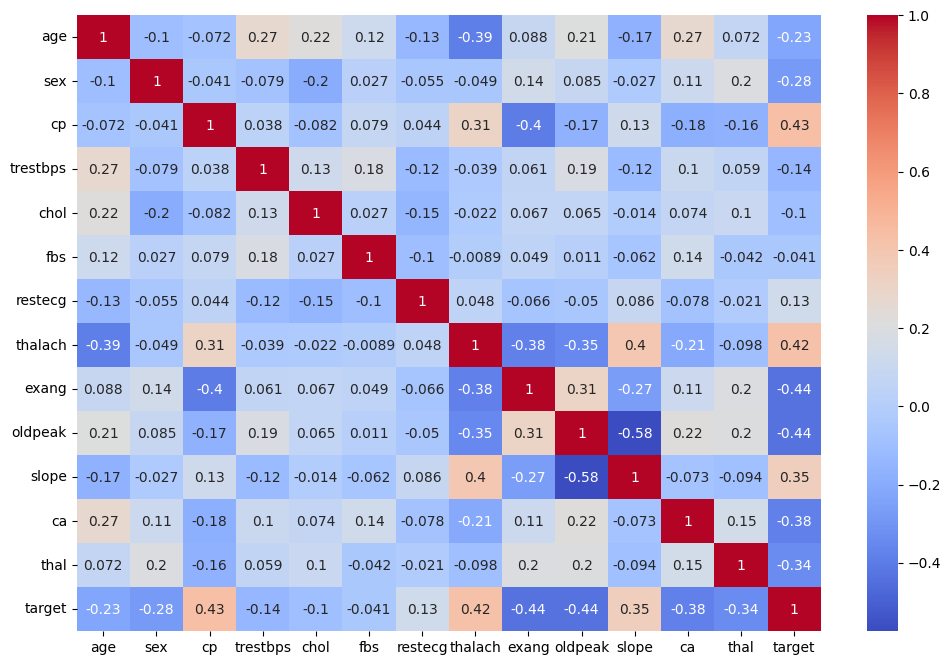

In [63]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

4.3 Feature Distributions

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

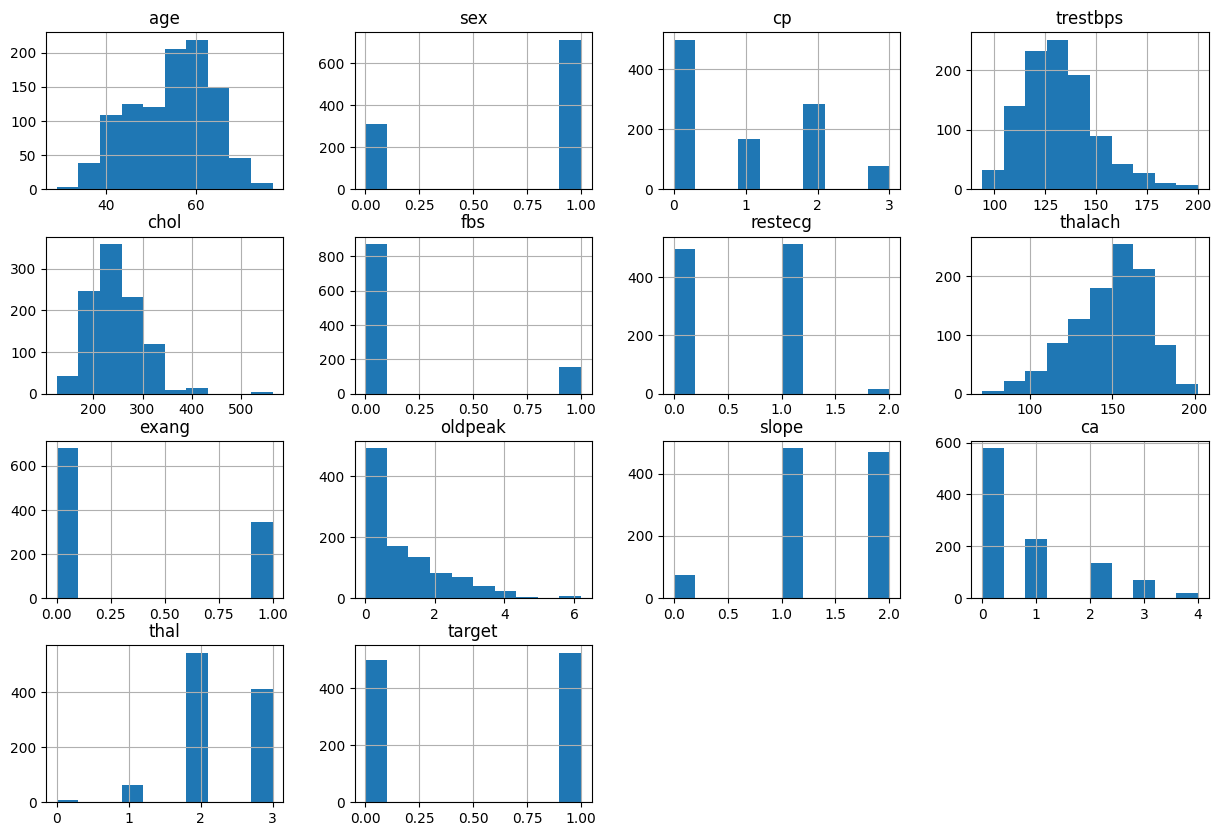

In [64]:
df.hist(figsize=(15,10))

### SECTION 5 — Деректерді алдын ала өңдеу
Модельді жаттықтыру алдында деректерді дайындау:
* **X/y бөлу:** Тәуелсіз айнымалыларды (белгілер) және нысаналы айнымалыны (target) ажырату.
* **Train/Test Split:** Деректерді жаттықтыру (80%) және тексеру (20%) жиындарына бөлу.
* **Standardization:** Барлық сандық мәндерді бір шкалаға (мысалы, -3-тен 3-ке дейін) келтіру. Бұл Logistic Regression алгоритмінің дұрыс жұмыс істеуі үшін өте маңызды.

In [65]:
X = df.drop('target', axis=1)
y = df['target']

5.2 Train/Test Split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

5.3 Standardization

In [67]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### SECTION 6 — Классикалық ML моделі (Logistic Regression)
Логистикалық регрессия — бұл екілік классификацияға арналған базалық алгоритм. Ол медицинада аурудың ықтималдығын есептеу үшін жиі қолданылады. Мұнда біз модельді жаттықтырып, оның алғашқы нәтижелерін аламыз.

In [68]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

Evaluation

In [69]:
print(classification_report(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205

[[70 30]
 [ 9 96]]
Accuracy: 0.8097560975609757


### SECTION 7 — Ансамбльдік әдіс (Random Forest)
Random Forest — бірнеше шешім ағаштарының (decision trees) жиынтығынан тұратын қуатты алгоритм. "Көпшілік дауыс беру" принципі бойынша жұмыс істейтіндіктен, ол классикалық модельдерге қарағанда дәлірек нәтиже беруге бейім.

In [70]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

### SECTION 8 — Гиперпараметрлерді баптау (GridSearchCV)
Модельдің ең үздік нұсқасын табу үшін біз қолмен таңдамай, автоматты түрде әртүрлі параметрлерді (ағаштар саны, тереңдігі) салыстырамыз. `cv=5` (cross-validation) деректерді 5-ке бөліп тексеру арқылы модельдің тұрақтылығын қамтамасыз етеді.

In [71]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

Best Parameters

In [72]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


SECTION 9 — Tuned Model Evaluation

In [73]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



### SECTION 10 — Салыстырмалы талдау
Бұл — жобаның ең маңызды бөлімі. Біз екі модельді:
1. **Accuracy:** Жалпы дәлдік.
2. **Recall:** Ауру адамдарды қаншалықты қатесіз таба алдық? (Медицинада ең маңыздысы).
3. **ROC-AUC:** Модельдің кластарды ажырата алу қабілеті.
Осы көрсеткіштер арқылы қай модельдің тиімді екенін анықтаймыз.

In [74]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, best_pred)
    ],
    
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, best_pred)
    ],
    
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, best_pred)
    ],
    
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, best_pred)
    ]
})

print("\nМодельдерді салыстыру:")
print(results)


Модельдерді салыстыру:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.809756   0.761905  0.914286  0.831169
1        Random Forest  1.000000   1.000000  1.000000  1.000000


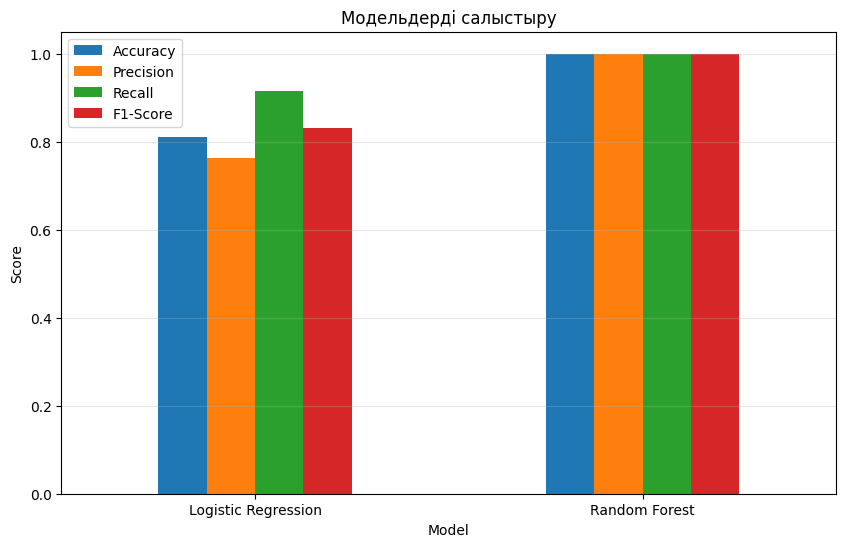

In [78]:
results.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]].plot(kind='bar', figsize=(10,6))

plt.title("Модельдерді салыстыру")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

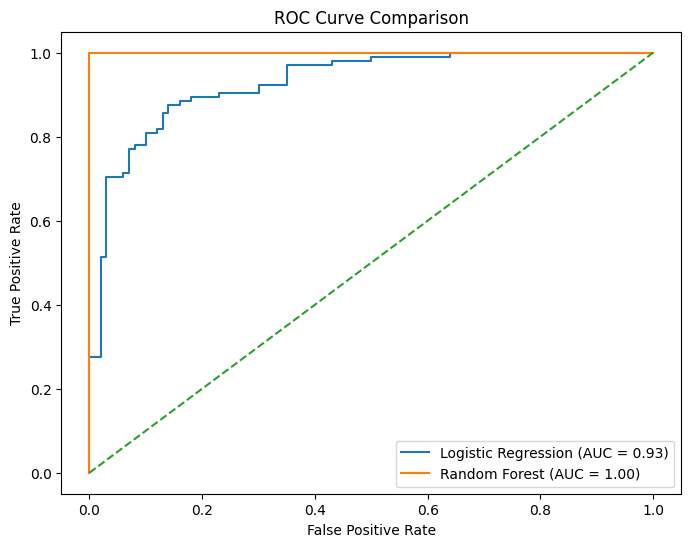

In [79]:
# Logistic Regression probabilities
lr_prob = lr_model.predict_proba(X_test)[:,1]

# Random Forest probabilities
rf_prob = best_model.predict_proba(X_test)[:,1]

# ROC points
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# ROC-AUC scores
lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

# Plot
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.2f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

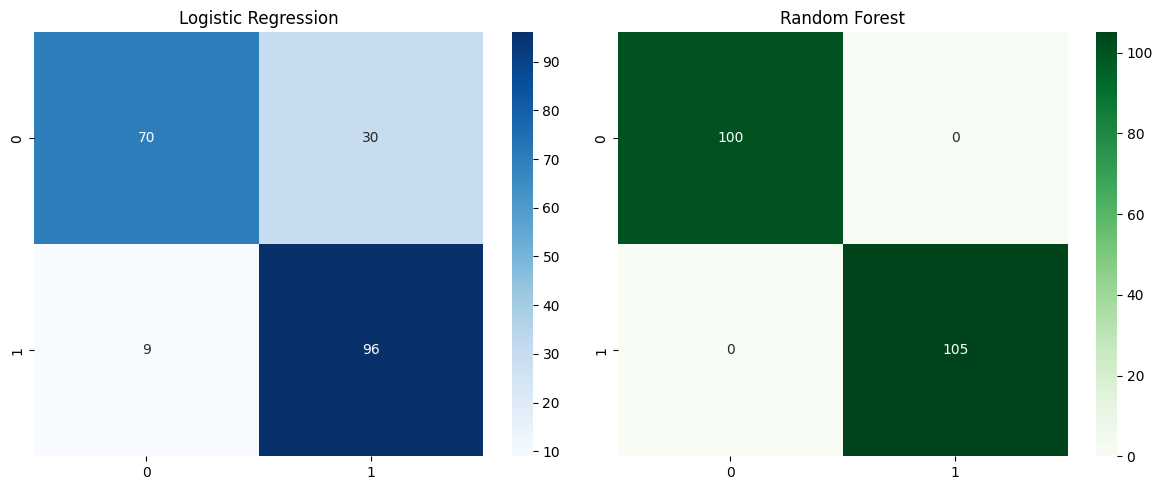

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression
sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")

# Random Forest
sns.heatmap(
    confusion_matrix(y_test, best_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

### SECTION 11 — Визуализация және Белгілердің маңыздылығы
* **Confusion Matrix:** Қай жерде қате жіберілгенін (неше сау адамды ауру дедік және керісінше) көрсетеді.
* **Feature Importance:** Жүрек ауруын анықтауда қай фактордың (мысалы, жас, қан қысымы немесе холестерин) ең үлкен рөл атқарғанын көрсетеді.

<Axes: >

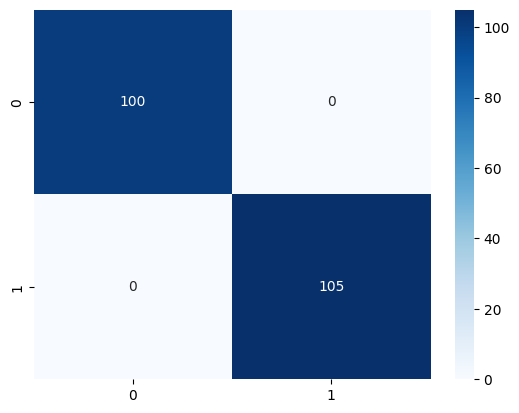

In [75]:
cm = confusion_matrix(y_test, best_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

ROC Curve

ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

[[100   0]
 [  0 105]]
1.0


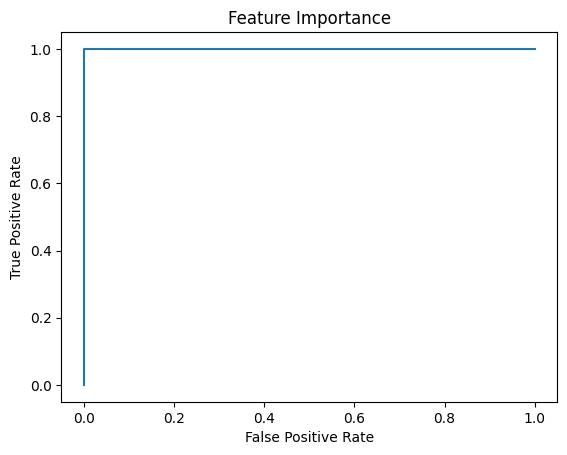

In [76]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Feature Importance")
print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(accuracy_score(y_test, rf_pred))

Feature Importance

<Axes: >

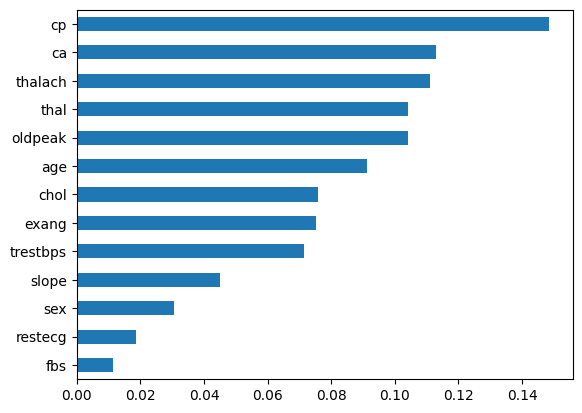

In [77]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')